In [9]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [10]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_all

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_all


In [11]:
# =========================
# Input
# =========================
DREP_DIR = 'data_tables'
OUT_DIR = 'drep_plots'
os.makedirs(OUT_DIR, exist_ok=True)

CDB = os.path.join(DREP_DIR, "Cdb.csv")
WDB = os.path.join(DREP_DIR, "Wdb.csv")

cdb = pd.read_csv(CDB)
wdb = pd.read_csv(WDB)

print(cdb.head())
print(wdb.head())
print(cdb.columns.tolist())
print(wdb.columns.tolist())

                        genome secondary_cluster  threshold cluster_method  \
0            C09_concoct.82.fa               1_1       0.05        average   
1       C10_metabat2.bins.1.fa               1_1       0.05        average   
2            C11_concoct.25.fa               1_1       0.05        average   
3  C01_metabat2.bins.82_sub.fa               2_1       0.05        average   
4      C09_metabat2.bins.45.fa               2_1       0.05        average   

  comparison_algorithm  primary_cluster  
0                ANImf                1  
1                ANImf                1  
2                ANImf                1  
3                ANImf                2  
4                ANImf                2  
                    genome cluster       score
0        C11_concoct.25.fa     1_1  102.469939
1  C09_metabat2.bins.45.fa     2_1   95.778745
2        C02_concoct.31.fa     3_1  101.826992
3               C02.028.fa     4_1   90.982427
4  C03_metabat2.bins.69.fa     5_0   54.5154

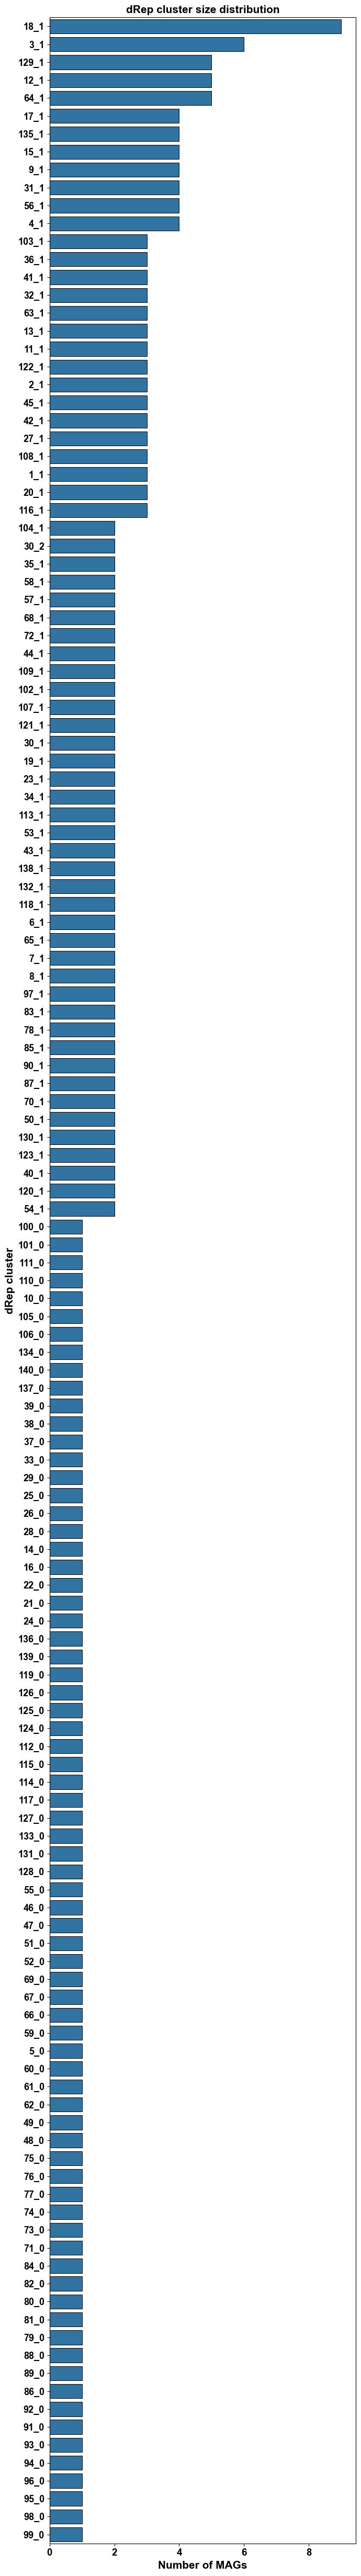

In [15]:
# dRep version마다 column명이 다를 수 있어 후보를 지정
cluster_col_candidates = ["secondary_cluster", "cluster", "cluster_ID", "primary_cluster"]
genome_col_candidates = ["genome", "genome_id", "genome_ID"]

cluster_col = next((c for c in cluster_col_candidates if c in cdb.columns), None)
genome_col = next((c for c in genome_col_candidates if c in cdb.columns), None)

if cluster_col is None:
    raise ValueError(f"Cluster column not found. Columns: {cdb.columns.tolist()}")

if genome_col is None:
    genome_col = cdb.columns[0]

cluster_counts = (
    cdb.groupby(cluster_col)[genome_col]
    .nunique()
    .reset_index(name="MAG_count")
    .sort_values("MAG_count", ascending=False)
)

plt.figure(figsize=(7, max(4, len(cluster_counts) * 0.35)))

ax = sns.barplot(
    data=cluster_counts,
    y=cluster_col,
    x="MAG_count",
    edgecolor="black",
    linewidth=0.7
)

plt.xlabel("Number of MAGs", fontsize=15, fontweight="bold")
plt.ylabel("dRep cluster", fontsize=15, fontweight="bold")
plt.title("dRep cluster size distribution", fontsize=15, fontweight="bold")

plt.xticks(fontsize=13.5, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dRep_cluster_size_distribution.png"), dpi=500, bbox_inches="tight")
plt.show()

In [16]:
print(wdb.columns.tolist())
print(wdb.head())

['genome', 'cluster', 'score']
                    genome cluster       score
0        C11_concoct.25.fa     1_1  102.469939
1  C09_metabat2.bins.45.fa     2_1   95.778745
2        C02_concoct.31.fa     3_1  101.826992
3               C02.028.fa     4_1   90.982427
4  C03_metabat2.bins.69.fa     5_0   54.515407


In [17]:
winner_candidates = ["winner", "genome", "genome_id", "genome_ID"]
cluster_candidates = ["secondary_cluster", "cluster", "cluster_ID"]

winner_col = next((c for c in winner_candidates if c in wdb.columns), None)
w_cluster_col = next((c for c in cluster_candidates if c in wdb.columns), None)

if winner_col is None:
    raise ValueError(f"Winner/genome column not found. Columns: {wdb.columns.tolist()}")

rep_df = wdb.copy()
rep_df["Representative_MAG"] = rep_df[winner_col]

print(rep_df[[w_cluster_col, "Representative_MAG"]].head() if w_cluster_col else rep_df[["Representative_MAG"]].head())

  cluster       Representative_MAG
0     1_1        C11_concoct.25.fa
1     2_1  C09_metabat2.bins.45.fa
2     3_1        C02_concoct.31.fa
3     4_1               C02.028.fa
4     5_0  C03_metabat2.bins.69.fa


In [18]:
rep_df.to_csv(os.path.join(OUT_DIR, "dRep_representative_MAGs.csv"), index=False)